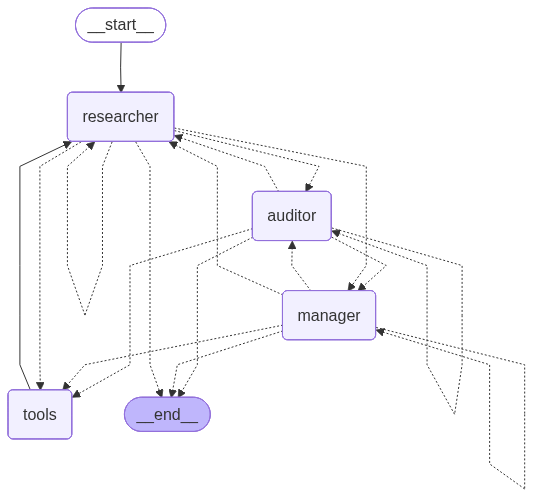

In [1]:
import os
import json
import ast
import time
from typing import Annotated, Sequence, TypedDict, List, Literal, Union
from dotenv import load_dotenv

from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_community.callbacks.manager import get_openai_callback

load_dotenv()

# --- STEP 1: Shared A2A State ---
class A2AState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str
    project_files: List[str]

# --- STEP 2: Tools (Shared by Agents) ---
benchmark_context = {}

@tool
def verify_file_presence(filename: str) -> str:
    """Checks if a filename exists in the project. Use to validate candidate lists."""
    return f"Verification: {filename} is checked against current project structure."

@tool
def get_file_snippet(filename: str, line_start: int = 1, line_end: int = 20) -> str:
    """Reads file content to resolve dependency ambiguity."""
    file_content = benchmark_context.get(filename, "Error: File not found.")
    if file_content == "Error: File not found.": return file_content
    lines = file_content.split('\n')
    return f"Content of {filename}:\n---\n" + "\n".join(lines[line_start-1:line_end])

tools = [verify_file_presence, get_file_snippet]
tool_node = ToolNode(tools)

# --- STEP 3: Setup LLM ---
llm = ChatAnthropic(
    model="claude-3-haiku-20240307", # Use your preferred model
    temperature=0.1,
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY")
).bind_tools(tools)

# --- STEP 4: Agent Specialist Nodes ---

def call_researcher(state: A2AState):
    """Phase 1: Extraction & Dependency Logic."""
    lang = state.get("language", "python")
    system_prompt = (
        f"You are the Researcher (Expert in {lang}).\n"
        "TASK: Extract all file-to-file dependencies.\n"
        "LOGIC: If File B imports File A, File B depends on File A.\n"
        "ACTION: Use 'get_file_snippet' for any complex imports.\n"
        "PROTOCOL: When finished, message the Auditor: '@Auditor, please verify: [file_list]'"
    )
    response = llm.invoke([SystemMessage(content=system_prompt)] + list(state["messages"]))
    return {"messages": [response]}

def call_auditor(state: A2AState):
    """Phase 2: Fact-Checking & Validation."""
    system_prompt = (
        "You are the Auditor.\n"
        "TASK: Validate the Researcher's list against reality.\n"
        "ACTION: You MUST use 'verify_file_presence' for EVERY file in the list.\n"
        "REJECTION: If a file is missing, tell the Researcher to fix it.\n"
        "PROTOCOL: If all exist, message the Manager: '@Manager, list is verified: [file_list]'"
    )
    response = llm.invoke([SystemMessage(content=system_prompt)] + list(state["messages"]))
    return {"messages": [response]}

def call_manager(state: A2AState):
    """Phase 3: Topological Sorting & Formatting."""
    system_prompt = (
        "You are the Manager.\n"
        "TASK: Finalize the Dependency List.\n"
        "CONSTRAINTS:\n"
        "1. TOPOLOGICAL SORT: If B depends on A, A MUST come before B.\n"
        "2. FORMAT: Output ONLY a unique Python list of strings. No prose.\n"
        "PROTOCOL: Respond with the list, then say 'FINAL_OUTPUT'."
    )
    # Manager doesn't need tools, just the messages
    response = llm.invoke([SystemMessage(content=system_prompt)] + list(state["messages"]))
    return {"messages": [response]}

# --- STEP 5: The A2A Protocol Router ---
def route_a2a(state: A2AState) -> Literal["tools", "auditor", "manager", "researcher", "__end__"]:
    """The 'Post Office' logic governing agent transitions."""
    last_message = state["messages"][-1]
    
    # 1. Check for Tool Calls (Standard ReAct behavior)
    if last_message.tool_calls:
        return "tools"
    
    content = last_message.content
    # 2. Check for A2A Hand-offs
    if "@Auditor" in content:
        return "auditor"
    if "@Manager" in content:
        return "manager"
    if "@Researcher" in content or "missing" in content.lower():
        return "researcher"
    if "FINAL_OUTPUT" in content:
        return END
    
    return "researcher" # Default fallback

# --- STEP 6: Graph Construction ---
workflow = StateGraph(A2AState)

workflow.add_node("researcher", call_researcher)
workflow.add_node("auditor", call_auditor)
workflow.add_node("manager", call_manager)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("researcher")

# Routing after each agent
workflow.add_conditional_edges("researcher", route_a2a)
workflow.add_conditional_edges("auditor", route_a2a)
workflow.add_conditional_edges("manager", route_a2a)

# Standard tool return path (always back to the agent who called it)
workflow.add_edge("tools", "researcher") # Simplified for now

app = workflow.compile()
app